# U-Net from Scratch

**References**

[1] Ronneberger, O., Fischer, P., & Brox, T. (2015, October). U-net: Convolutional networks for biomedical image segmentation. In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Cham: Springer international publishing.

## Required Imports

In [37]:
import os

import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy.ndimage as ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchinfo import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch.utils.data import Dataset, DataLoader

## Data Preprocessing

### Loading from Data

#### The Image

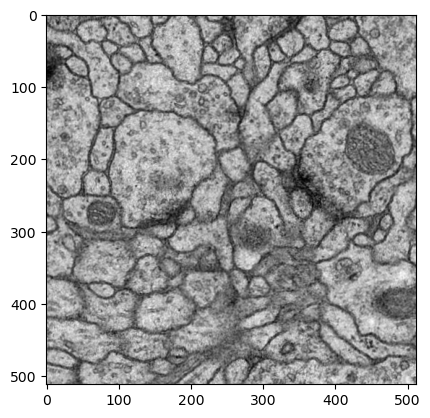

In [2]:
image = cv2.imread('../../data/isbi2012challenge/train/imgs/frame_0001.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')

#### The Mask Label

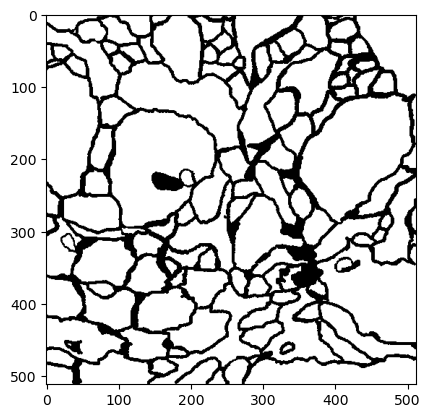

In [39]:
mask = cv2.imread('../../data/isbi2012challenge/train/labels/frame_0001.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap='gray')

### Data Augmentation: The Elastic Deformation

Because the training data for the task is very limited, the paper proposes to use *Elastic Deformation* to the available training images, which allows the network to learn invariance to such deformations without the need to see these transformations in the annotated image corpus. (as in the original unet paper).

In the case of microscopical images, we majorly need shift and rotation invariance as well as robustness to deformations and gray value variations. Specifically, the paper proposes to augment the training dataset by generating smooth deformations using random displacement vectors on a coarse $3 \times 3$ grid, which are sampled from a Gaussian distribution with $10$ pixels standard deviation. The pixelwise displacements are computed using *bicubic interpolation*. Also note that the dropout layers at the end of the contracting path perform further data augmentation implicitly.

In [3]:
def elastic_transform(image, grid_size=3, std=10):
    """
    Perform elastic deformation on the input grayscale image. This is an explanatory implementation of
    the elastic deformation process. We will use albumentations library to perform the elastic deformation
    in the data pipeline.
    
    Args:
        image: grayscale image in numpy array of shape (H, W)
        grid_size: size of the grid for deformation, default to 3 x 3 grid
        std: standard deviation of the Gaussian distribution, default to 10 pixels
        
    Returns:
        deformed_image: numpy array of shape (H, W, C)
    """
    h, w = image.shape

    # 3 x 3 coarse grid of random displacement vectors sampled from Gaussian
    # distribution with std = 10 pixels
    x_displacements = np.random.normal(0, std, size=(grid_size, grid_size)) # 3 x 3 grid for x displacements
    y_displacements = np.random.normal(0, std, size=(grid_size, grid_size)) # 3 x 3 grid for y displacements

    # create a grid of coordinates
    x_coordinates = np.linspace(start=0, stop=grid_size - 1, num=w)
    y_coordinates = np.linspace(start=0, stop=grid_size - 1, num=h)
    grid = np.meshgrid(x_coordinates, y_coordinates, indexing='ij') # using indexing='ij' to match the shape of the displacements

    # compute the displacement values
    dx = ndimage.map_coordinates(x_displacements, grid)
    dy = ndimage.map_coordinates(y_displacements, grid)

    # create a coordinate grid for the deformed image
    output_coordinates_y, output_coordinates_x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij') # output image coordinates

    # apply displacements to the coordinates of the deformed image
    output_coordinates_y = output_coordinates_y + dy
    output_coordinates_x = output_coordinates_x + dx

    # compute the pixel values of the deformed image using bicubic interpolation
    deformed_image = ndimage.map_coordinates(image, [output_coordinates_y, output_coordinates_x])

    return deformed_image

Deform a sample,

In [4]:
image.shape

(512, 512)

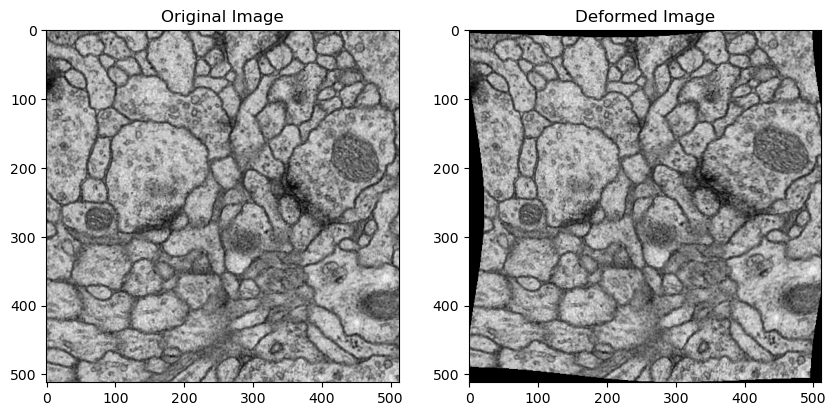

In [5]:
deformed_image = elastic_transform(image)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(deformed_image, cmap='gray')
axes[1].set_title('Deformed Image')
plt.show()

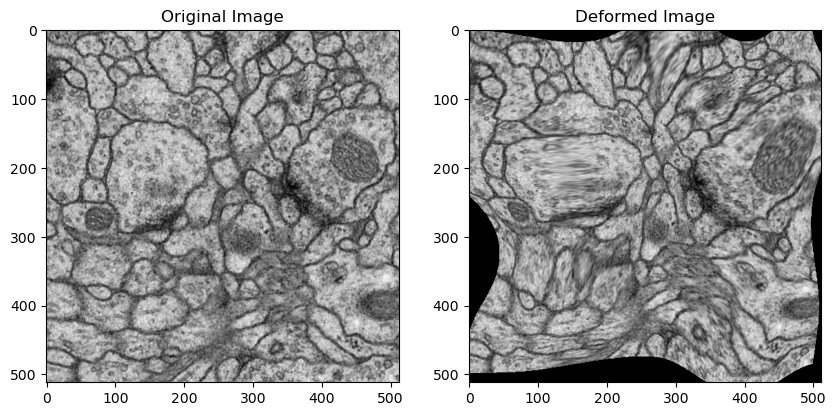

In [6]:
# another deformation
deformed_image = elastic_transform(image, grid_size=6, std=20)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(deformed_image, cmap='gray')
axes[1].set_title('Deformed Image')
plt.show()

### Define Dataloaders

#### The Train and Test Data Transforms

In [23]:
train_transform = A.Compose([
    # 1. Resize
    A.Resize(height=256, width=256),

    # 2. Geometric Transformations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # 3. Elastic Deformation
    A.ElasticTransform(p=0.5, alpha=1, sigma=10),
    
    # 4. Grid Distortion
    A.GridDistortion(p=0.5),

    # 5. Shift/Rotation
    A.Affine(
        translate_percent={"x": (-0.0625, 0.0625), "y": (-0.0625, 0.0625)},
        scale=(0.9, 1.1),
        rotate=(-45, 45),
        p=0.5
    ),

    # 6. Normalization and Conversion to Tensor
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])    

In [24]:
test_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

#### The Dataset Classes

In [25]:
class ISBI2012Dataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]

        image_path = os.path.join(self.image_dir, image)
        mask_path = os.path.join(self.mask_dir, image)

        # 1. Load the image and mask and convert to numpy arrays for albumentations
        image = np.array(cv2.imread(image_path))
        mask = np.array(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE))

        # 2. Apply the transformations
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # 3. Return the image and mask, ensure the mask is long tensor for cross-entropy loss
        # and the image is already a FloatTensor from the ToTensorV2() transform in the transform pipeline
        return image, mask

In [32]:
train_dataset = ISBI2012Dataset(
    image_dir='../../data/isbi2012challenge/train/imgs',
    mask_dir='../../data/isbi2012challenge/train/labels',
    transform=train_transform
)

test_dataset = ISBI2012Dataset(
    image_dir='../../data/isbi2012challenge/test/imgs',
    mask_dir='../../data/isbi2012challenge/test/labels',
    transform=test_transform
)

#### The Dataloaders

In [33]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [34]:
# Test the Dataloaders
for batch in train_loader:
    images, masks = batch
    print(images.shape)
    print(masks.shape)
    break

torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256])


## The U-Net Model Architecture

Here we implement the U-Net architecture from the original paper.

![U-Net Model Architecture](./imgs/unet.png)

The model architecture consists of a contracting path (left side) and an expansive path (right side),

- Contractive Path: similar to a typical convolutional neural network, consisting of two repeated $3 \times 3$ unpadded convolutions, each followed by a ReLU and a $2 \times 2$ max pooling operation with stride $2$ for downsampling, where at each downsampling step we double the number of feature channels.
- Expansive Path: at each step in the expansive path, we perform upsampling of the feature map followed by a $2 x 2$ convolution (*"up-convolution"*) that halves the number of feature channels, we also concatenate the upsampled feature map with the cropped feature map from the corresponding step in the contractive path, and two $3 \times 3$ convolutions, each followed by a ReLU. **Note** that the cropping is necessary due to the loss of border pixels in every convolution.

At the final layer a $1 \times 1$ convolution is used to map each $64$ component feature vector to a desired number of classes. The U-Net has a total of $23$ convolutional layers.

In [14]:
class Contraction(nn.Module):
    """
    Contractive Path
    """
    def __init__(self, in_channels, out_channels):
        super(Contraction, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        downsampled = self.relu(x) # we save the downsampled output for shortcut connection in the expansive path
        pooled = self.maxpool(downsampled)
        return downsampled, pooled

In [15]:
class Expansion(nn.Module):
    """
    Expansive Path
    """
    def __init__(self, in_channels, out_channels):
        super(Expansion, self).__init__()

        self.upconv1 = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, downsampled):
        x = self.upconv1(x)
        x = torch.cat([x, downsampled], dim=1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        return x

In [16]:
class UNet(nn.Module):
    """
    U-Net Model
    """
    def __init__(self, in_channels, num_classes):
        super(UNet, self).__init__()

        self.contraction1 = Contraction(in_channels, 64)
        self.contraction2 = Contraction(64, 128)
        self.contraction3 = Contraction(128, 256)
        self.contraction4 = Contraction(256, 512)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.expansion1 = Expansion(1024, 512)
        self.expansion2 = Expansion(512, 256)
        self.expansion3 = Expansion(256, 128)
        self.expansion4 = Expansion(128, 64)

        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        downsampled1, pool1 = self.contraction1(x)
        downsampled2, pool2 = self.contraction2(pool1)
        downsampled3, pool3 = self.contraction3(pool2)
        downsampled4, pool4 = self.contraction4(pool3)

        bottleneck = self.bottleneck(pool4)

        upsampled1 = self.expansion1(bottleneck, downsampled4)
        upsampled2 = self.expansion2(upsampled1, downsampled3)
        upsampled3 = self.expansion3(upsampled2, downsampled2)
        upsampled4 = self.expansion4(upsampled3, downsampled1)

        return self.output_conv(upsampled4)

In [17]:
# Test the U-Net model
model = UNet(in_channels=3, num_classes=10)
x = torch.randn(1, 3, 512, 512)
output = model(x)
print(output.shape)

torch.Size([1, 10, 512, 512])


In [38]:
summary(model, input_size=(1, 3, 512, 512))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 10, 512, 512]         --
├─Contraction: 1-1                       [1, 64, 512, 512]         --
│    └─Conv2d: 2-1                       [1, 64, 512, 512]         1,792
│    └─ReLU: 2-2                         [1, 64, 512, 512]         --
│    └─Conv2d: 2-3                       [1, 64, 512, 512]         36,928
│    └─ReLU: 2-4                         [1, 64, 512, 512]         --
│    └─MaxPool2d: 2-5                    [1, 64, 256, 256]         --
├─Contraction: 1-2                       [1, 128, 256, 256]        --
│    └─Conv2d: 2-6                       [1, 128, 256, 256]        73,856
│    └─ReLU: 2-7                         [1, 128, 256, 256]        --
│    └─Conv2d: 2-8                       [1, 128, 256, 256]        147,584
│    └─ReLU: 2-9                         [1, 128, 256, 256]        --
│    └─MaxPool2d: 2-10                   [1, 128, 128, 128]        --

## Training

### Define the Loss Functions